## Manually designed second-order notch filter

We want a digital notch filter with the following properties:

- attenuation of at least 40 dB at $f_0=20 $ Hz
- bandwidth of $\Delta f = 4 $ Hz
- the gain at 0 Hz should be 0 dB. 
- sampling frequency is $f_s=160 $ Hz

Let's find out the form of the transfer function $H(z)$.

---
### Solution
The normalized angular notch frequency is
$$
\omega_0 = 2\pi \frac{f_0}{f_s}
= 2\pi \frac{20}{160}
= \frac{\pi}{4}.
$$
while the normalized half bandwidth $\delta = 2\pi\frac{\Delta f}{2f_s}=\frac{\pi}{40}\approx 0,08$

<img src="notch1.png" width=150> 
The expression of the gain based on the properties of the transfer function:
$$
\text{Gain} = k\dfrac{\prod\text{zero distances}}{\prod\text{pole distances}}
$$
Because of the strong attenuation the zero(s) should be close to the notch frequency point, we'll choose it to be ON the unit circle (point $Z$.)

Because of the symmetry between the two cut off frequencies (18 Hz & 22 Hz) with respect to the notch frequency (20 Hz) we can place the pole on the same line as the zero but within the circle.

<img src="notch2.png" width=150> 

Both the zero and the pole are complex so we introduce their complex conjugate so that all coefficients in the transfer function could be real. Formally:
$$
z_{1,2} = e^{\pm j\omega_0}\ ,\quad
p_{1,2} = d e^{\pm j\omega_0},
$$

The closer $d$ is to 1, the narrower the notch becomes.

The simplest transfer function with the two zeros and two poles is

$$
{H(z)
=
k
\frac{(z-e^{j\omega_0})(z-e^{-j\omega_0})}
     {(z-d e^{j\omega_0})(z-d e^{-j\omega_0})}.}
$$

Using

$$
(z-e^{j\omega_0})(z-e^{-j\omega_0})
=
z^2 - 2\cos(\omega_0)z + 1,
$$

and

$$
(z-d e^{j\omega_0})(z-d e^{-j\omega_0})
=
z^2 - 2d\cos(\omega_0)z + d^2,
$$

we get

$$
H(z)
=
k
\frac{z^2 - 2\cos(\omega_0)z + 1}
     {z^2 - 2d\cos(\omega_0)z + d^2}.
$$

For

$$
\omega_0 = \frac{\pi}{4},
\qquad
\cos\left(\frac{\pi}{4}\right)=\frac{1}{\sqrt{2}},
$$

this becomes

$$
H(z)
=
k
\frac{z^2 - \sqrt{2}z + 1}
     {z^2 - d\sqrt{2}z + d^2}.
$$

Now we have to set the two parameters $d$ and $k$.

We make two assumptions:

- Assuming that the pole $p_1$ and the zero $z_1$ are both close to the the frequency point $A$ and to each other, point $A$ (and also $B$) will be approximately equally far from the conjugate pole $p_2$ and the conjugate zero $z_2$.
Consequently, the ratio of the corresponding distances can be approximated by unity and only the lengths of the $AZ$ and $AP$ will play role in the gain. 
- $k$ will be close to  one,therefore we'll set it to one.
- because of a very short $|AZ|$ the angle $\angle AZP\approx \pi/2$.
 
So Gain(A)$\approx  \frac{|AZ|}{|AP|}\approx \frac{0,08}{\sqrt{(1-d)^2+(0,08)^2}}$=-3 dB = $\frac{1}{\sqrt{2}} \rightarrow 1-d=0,08 \rightarrow d=0,92$.

$$
\boxed{H(z)=\frac{z^2 - \sqrt{2}z + 1}
     {z^2 - 0.92\sqrt{2}z + 0.92^2}.}
$$

If we represent the corresponding Bode diagram we get the expected negative peaks at $\pm 20 Hz$.

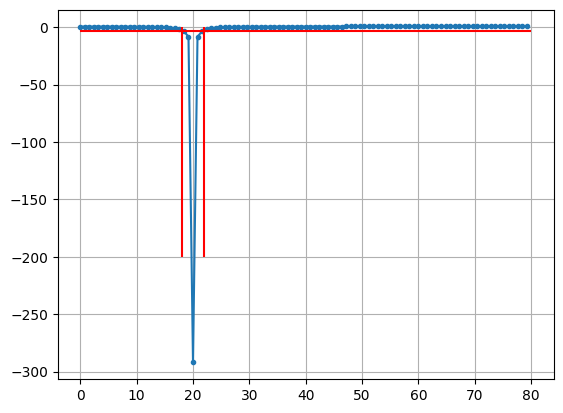

In [14]:
fs = 160
fn = fs/2
d = 1 - pi/40
ds = signal.dlti([1, -sqrt(2), 1], [1, -sqrt(2)*d, d**2])
w, gain, phase = ds.bode()
f = w/(2*pi)*fs
plot(f, gain, '.-', label='bode')
hlines([-3], [0], [80], color='red')
vlines([18, 22], [0, 0], [-200, -200],color='red')
grid()

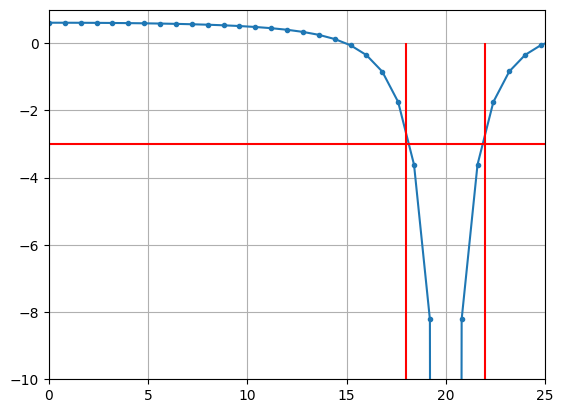

In [15]:
# Let's see the in detail how well we satisfied the requirements (DC gain + cut off freq. gain)
plot(f, gain, '.-', label='bode')
hlines([-3], [0], [80], color='red')
vlines([18, 22], [0, 0], [-200, -200],color='red')
xlim([0.0, 25])
ylim([-10, 1])
grid()

## Normalizing the DC gain

However, at 0 Hz the gain is not exactly unity. We can fix it by reintroducing $k$ such that $|H(e^{j0})| = 1$: 

$$
k = \left|\frac{1 - 0.92\sqrt{2}+0.92^2}{2 - \sqrt{2}}\right|\approx 0.965
$$

Thus the filter coefficients are

$$
b = k[1,\ -\sqrt{2},\ 1],
$$

and

$$
a = [1,\ -0.92\sqrt{2},\ 0.92^2].
$$



0.9319904765357107


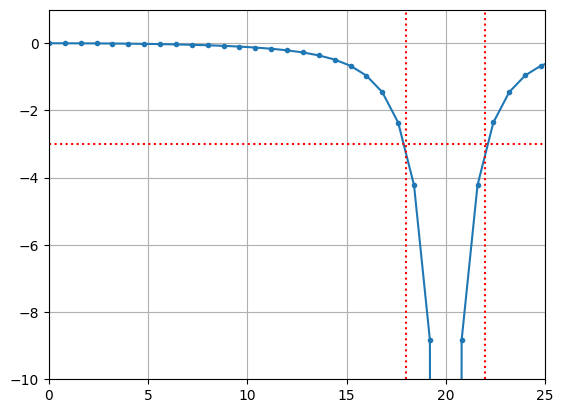

In [18]:
k = (1+d**2 - 2*d/sqrt(2))/(2 - sqrt(2))
print(k)
ds = signal.dlti(k*array([1, -sqrt(2), 1]), [1, -sqrt(2)*d, d**2])
w, gain, phase = ds.bode()
f = w/(2*pi)*fs
plot(f, gain, '.-', label='bode')
axvline(18, linestyle=':', color='red')
axvline(22, linestyle=':', color='red')
axhline(-3, linestyle=':', color='red')
xlim([0, 25])
ylim([-10, 1])
grid()

Observe that by normalizing the DC gain we (negligibly) distorted the the gain at the cutoff frequency.

---
## Designing a lowpass FIR filter using the Fourier (window) method

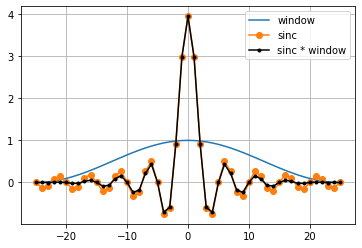

In [147]:
from pylab import *
from scipy import signal
fs, fl, N = 100, 20, 51
n = arange(N) - N//2 + 1e-12 # tiny shift so that we don't get 0/0
b_l = sin(2*pi*n*fl/fs)/(n/pi)
w = signal.windows.hann(N)
plot(n, w, '-', label='window')
plot(n, b_l, 'o-', label='sinc')
b_l *= w
plot(n, b_l, 'k.-', label='sinc * window')
legend()
grid()

/home/zsolt/.local/lib/python3.8/site-packages/scipy/signal/filter_design.py:1631: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


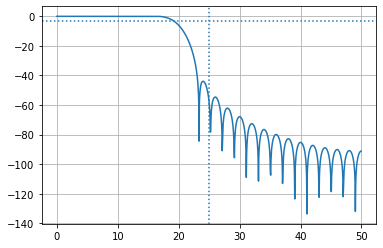

In [148]:
b_l /= b_l.sum() # Ensure that the gain at 0Hz is 1. 
ds = signal.dlti(b_l, [1], dt=1/fs)
o, gain, phase = ds.bode(w=1000)
plot(o/(2*pi), gain)
axvline(fc, linestyle=':')
axhline(-3, linestyle=':')
grid()


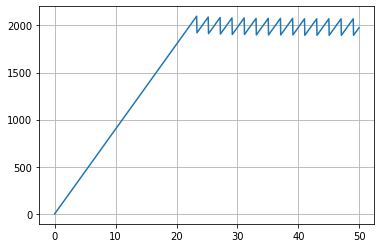

In [149]:
plot(o/(2*pi), phase)
grid()

## Designing a highpass FIR filter based on the above lowpass filter

/home/zsolt/.local/lib/python3.8/site-packages/scipy/signal/filter_design.py:1631: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


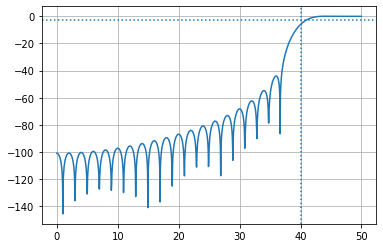

In [151]:
fh = 40
n = arange(N) - N//2+1e-12 # tiny shift so that we don't get 0/0
b_h = sin(2*pi*n*fh/fs)/(n*pi)
# or
n = arange(N) - N//2
b_h[n!=0] = sin(2*pi*n[n!=0]*fh/fs)/(n[n!=0]*pi)
b_h[n==0] = 2*fh/fs
#------
b_h *= w
b_h *= -1
b_h[N//2] += 1

b_h /= np.abs(np.sum(b_h * (-1) ** np.arange(N)))# Ensure that the gain at Nyquist is 1. 
ds = signal.dlti(b_h, [1], dt=1/fs)
# alternative 1 ----
o, gain, phase = ds.bode(w=1000)
f = o/(2*pi)
# alternative 2
#o, H = ds.freqresp(w=1000)
#gain, phase = 20*log10(abs(H)), angle(H)*180/pi
#f = o/(2*pi)*fs
#-------------------
plot(f, gain)
axvline(fh, linestyle=':')
axhline(-3, linestyle=':')
grid()

In [152]:
# gain at the highest freq. close to unity (0dB) because the last freq. is not exactly pi
print(gain[-1])

2.261329889137102e-05


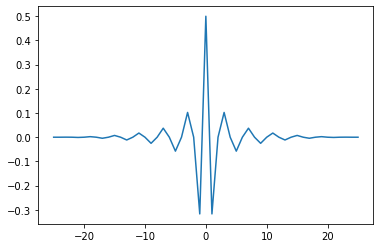

In [145]:
plot(n, b_h)

In [153]:
# Checking that indeed the gain at Nyquist is unity
o, H = signal.freqz(b_h, worN=array([pi]))
print(abs(H))

[1.]


## Designing a bandpass FIR filter based on the above lowpass filter

[ 0.00000000e+00 -1.89958217e-05 -3.34540534e-04  7.81760954e-04
  3.40547839e-04  1.90747526e-15 -8.24740155e-04 -4.93333558e-03
  6.68721433e-03  2.07496151e-03  9.22599832e-15 -3.35590722e-03
 -1.76566138e-02  2.16910474e-02  6.24092124e-03  2.62118704e-14
 -9.15927229e-03 -4.70182381e-02  5.72897868e-02  1.66604620e-02
  7.23825803e-14 -2.71203325e-02 -1.57543269e-01  2.41067058e-01
  1.15176935e-01 -4.00000000e-01  1.15176935e-01  2.41067058e-01
 -1.57543269e-01 -2.71203325e-02 -7.23543729e-14  1.66604620e-02
  5.72897868e-02 -4.70182381e-02 -9.15927229e-03 -2.61544513e-14
  6.24092124e-03  2.16910474e-02 -1.76566138e-02 -3.35590722e-03
 -9.21522404e-15  2.07496151e-03  6.68721433e-03 -4.93333558e-03
 -8.24740155e-04 -1.89909793e-15  3.40547839e-04  7.81760954e-04
 -3.34540534e-04 -1.89958217e-05 -0.00000000e+00]
(0.9992090867076934+1.8895987984773096e-12j)


/home/zsolt/.local/lib/python3.8/site-packages/scipy/signal/filter_design.py:1631: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


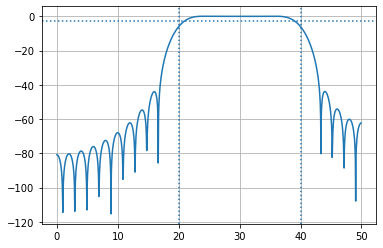

In [162]:
n = arange(N) - N//2+1e-12 # tiny shift so that we don't get 0/0
b_l = sin(2*pi*n*fl/fs)/(n*pi)
b_h = sin(2*pi*n*fh/fs)/(n*pi)
b = b_l - b_h
# taper
b *= w
print(b)
# normalization
f0 = (fl + fh)/2
omega0 = 2*pi*f0/fs
H0 = np.sum(b * np.exp(-1j * omega0 * np.arange(N)))
b /= abs(H0)
#------
ds = signal.dlti(b, [1], dt=1/fs)
o, gain, phase = ds.bode(w=1000)
f = o/(2*pi)
plot(f, gain)
axvline(fl, linestyle=':')
axvline(fh, linestyle=':')
axhline(-3, linestyle=':')
grid()
